# Bello dataset

In [ ]:
import pandas as pd
import numpy as np

# Only use bello_origin to construct the output
bello_origin = pd.read_csv("bello/DataBello_full.csv")[737:785]

# Reset index for bello_origin
bello_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_bello = bello_origin[["Epidemic_Week", "Cases"]].copy()
data_bello["CumulativeHumanInfected"] = data_bello["Cases"].cumsum()
data_bello.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_bello = data_bello.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_bello[col] = np.nan

# Set "Date" as index
data_bello.set_index("Date", inplace=True)
data_bello.to_csv("bello/data_cali.csv", index=True)

print(data_bello.shape)
data_bello.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
738,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
739,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
740,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
741,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
742,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import h5py
import pandas as pd

# Read the CSV file
data_bello = pd.read_csv('bello/data_cali.csv')
data_values = data_bello.iloc[:, 1:].values  # exclude the 'Date' column

# Reshape the data to (num_rows, num_compartments, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(data_values.shape[0], data_values.shape[1], 1)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = 'bello/data.h5'
with h5py.File(output_hdf5_path, 'w') as hdf:
    hdf.create_dataset('Dengue/true_counts', data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, 'r') as hdf:
    saved_shape = hdf['Dengue/true_counts'].shape
    print(f'Shape of true_counts from .h5 file {saved_shape}')

Shape of true_counts from .h5 file (48, 8, 1)


### Visualize the Dengue cases in Bello

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_csv_data(csv_file, time_column, value_columns, start=None, end=None, title="CSV Data Line Chart", xlabel="Time", ylabel="Value"):
    # Load data from CSV using pandas
    df = pd.read_csv(csv_file)
    df = df.iloc[start:end, :] \
        if start is not None or end is not None else df
    print(df)
    
    plt.figure(figsize=(10, 6))
    for col in value_columns:
        plt.plot(df[time_column], df[col], label=col)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

     Epidemic_Week  Cases
0                1      0
1                2      0
2                3      0
3                4      0
4                5      0
..             ...    ...
831            832     26
832            833     33
833            834     27
834            835     28
835            836      8

[836 rows x 2 columns]


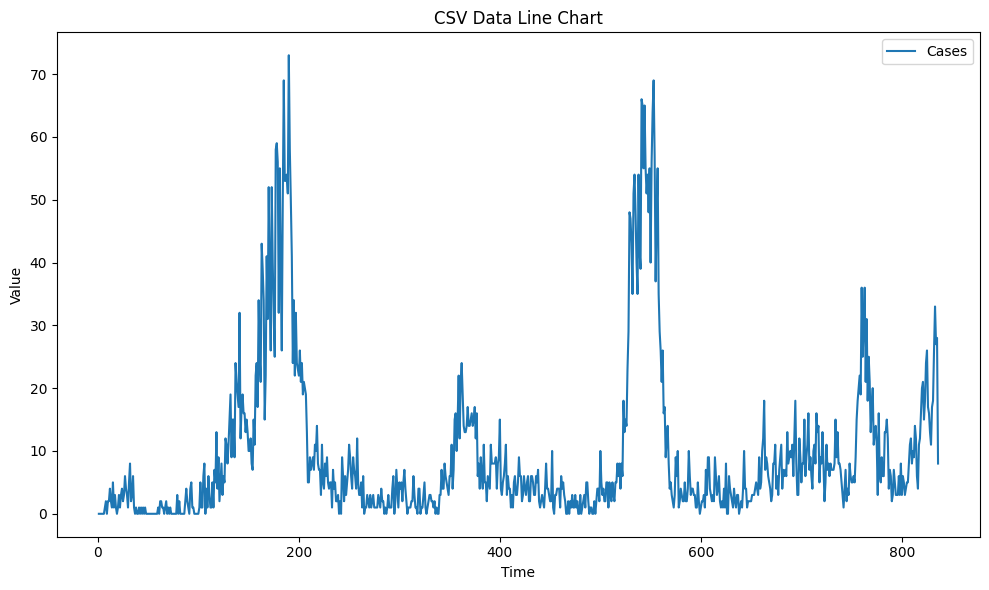

In [2]:
# Replace with the path to your CSV file
bello_csv = 'bello/DataBello_full.csv'
time_column = 'Epidemic_Week'
value_columns = ['Cases']

# Plot raw data
plot_csv_data(bello_csv, time_column, value_columns, start=None, end=None)

     Epidemic_Week  Cases
737            738      8
738            739      7
739            740      5
740            741      3
741            742      1
742            743      4
743            744      7
744            745      2
745            746      4
746            747      3
747            748      8
748            749      6
749            750      5
750            751      5
751            752      6
752            753      5
753            754      9
754            755     15
755            756     18
756            757     20
757            758     22
758            759     19
759            760     36
760            761     25
761            762     30
762            763     36
763            764     21
764            765     31
765            766     18
766            767     25
767            768     21
768            769     13
769            770     17
770            771     20
771            772     11
772            773     13
773            774     14
774         

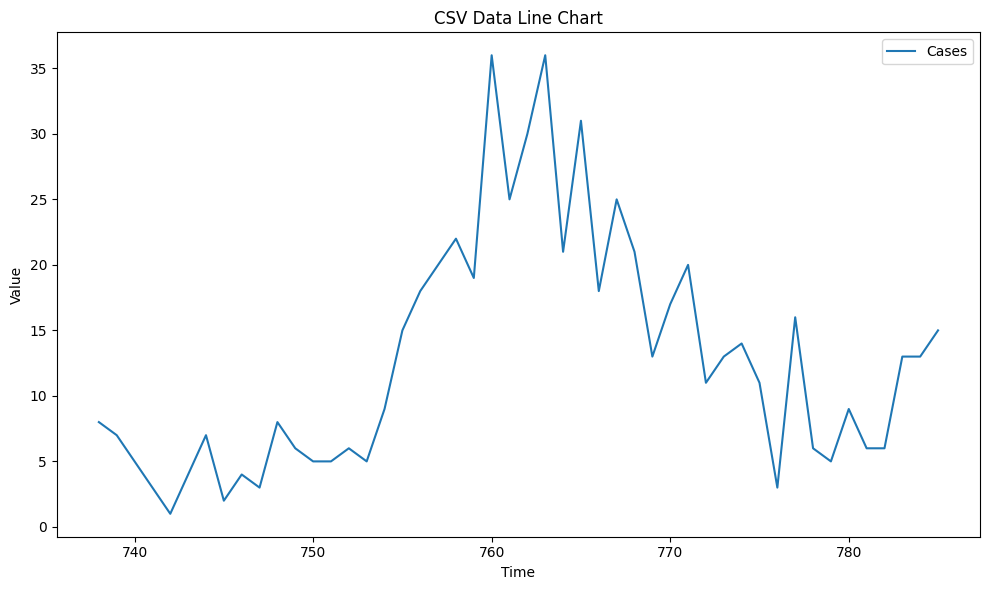

In [3]:
# Calibration (48 data points) (738-785)
plot_csv_data(bello_csv, time_column, value_columns, start=737, end=785)

In [4]:
import numpy as np

df = pd.read_csv(bello_csv)
df = df.iloc[737:785, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

737    2.197225
738    2.772589
739    3.044522
740    3.178054
741    3.218876
Name: CumulativeHumanInfected, dtype: float64
737     8.0
738    15.0
739    20.0
740    23.0
741    24.0
Name: CumulativeHumanInfected, dtype: float64
737      8
738     15
739     20
740     23
741     24
742     28
743     35
744     37
745     41
746     44
747     52
748     58
749     63
750     68
751     74
752     79
753     88
754    103
755    121
756    141
757    163
758    182
759    218
760    243
761    273
762    309
763    330
764    361
765    379
766    404
767    425
768    438
769    455
770    475
771    486
772    499
773    513
774    524
775    527
776    543
777    549
778    554
779    563
780    569
781    575
782    588
783    601
784    616
Name: CumulativeHumanInfected, dtype: int64


     Epidemic_Week  Cases
344            345      8
345            346      6
346            347      5
347            348      4
348            349      3
349            350      6
350            351      6
351            352     11
352            353      4
353            354      7
354            355     15
355            356     16
356            357     10
357            358     15
358            359     22
359            360     12
360            361     21
361            362     24
362            363     19
363            364     14
364            365     13
365            366     13
366            367     14
367            368     17
368            369     14
369            370     14
370            371     15
371            372     16
372            373     14
373            374     15
374            375     17
375            376     12
376            377     16
377            378      6
378            379      8
379            380      4
380            381      9
381         

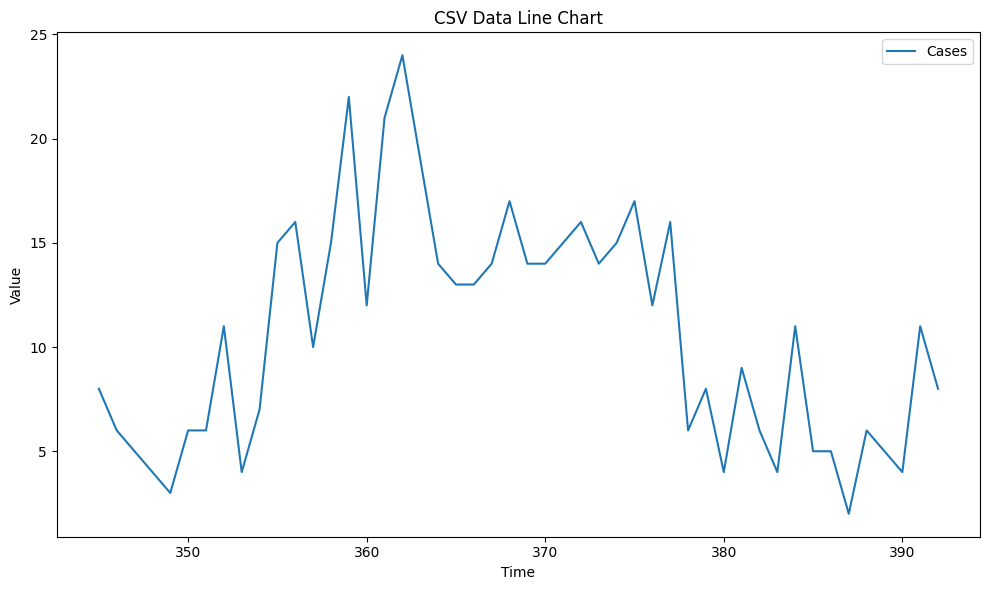

In [5]:
# Projection (62 data points) (346-394)
plot_csv_data(bello_csv, time_column, value_columns, start=344, end=392)

In [6]:
import numpy as np

df = pd.read_csv(bello_csv)
df = df.iloc[344:392, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

344    2.197225
345    2.708050
346    2.995732
347    3.178054
348    3.295837
Name: CumulativeHumanInfected, dtype: float64
344     8.0
345    14.0
346    19.0
347    23.0
348    26.0
Name: CumulativeHumanInfected, dtype: float64
344      8
345     14
346     19
347     23
348     26
349     32
350     38
351     49
352     53
353     60
354     75
355     91
356    101
357    116
358    138
359    150
360    171
361    195
362    214
363    228
364    241
365    254
366    268
367    285
368    299
369    313
370    328
371    344
372    358
373    373
374    390
375    402
376    418
377    424
378    432
379    436
380    445
381    451
382    455
383    466
384    471
385    476
386    478
387    484
388    489
389    493
390    504
391    512
Name: CumulativeHumanInfected, dtype: int64


In [20]:
import pandas as pd
import numpy as np

# Only use bello_origin to construct the output
bello_origin = pd.read_csv("bello/DataBello_full.csv")[344:392]

# Reset index for bello_origin
bello_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_bello = bello_origin[["Epidemic_Week", "Cases"]].copy()
data_bello["CumulativeHumanInfected"] = data_bello["Cases"].cumsum()
data_bello.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_bello = data_bello.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_bello[col] = np.nan

# Set "Date" as index
data_bello.set_index("Date", inplace=True)
data_bello.to_csv("bello/data_bello_proj.csv", index=True)

print(data_bello.shape)
data_bello.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
345,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
346,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
347,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
348,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
349,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Iquitos dataset

In [ ]:
import pandas as pd
import numpy as np

# Only use iquitos_origin to construct the output
iquitos_origin = pd.read_csv("iquitos/DataIquitos_full.csv")[265:313]

# Reset index for iquitos_origin
iquitos_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_iquitos = iquitos_origin[["Epidemic_Week", "Cases"]].copy()
data_iquitos["CumulativeHumanInfected"] = data_iquitos["Cases"].cumsum()
data_iquitos.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_iquitos = data_iquitos.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_iquitos[col] = np.nan

# Set "Date" as index
data_iquitos.set_index("Date", inplace=True)
data_iquitos.to_csv("iquitos/data_cali.csv", index=True)

print(data_iquitos.shape)
data_iquitos.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
266,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import h5py
import pandas as pd

# Read the CSV file
data_iquitos = pd.read_csv("iquitos/data_cali.csv")
data_values = data_iquitos.iloc[:, 1:].values  # exclude the 'Date' column

# Reshape the data to (number of rows, 7, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(
    data_values.shape[0], data_values.shape[1], 1
)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = "iquitos/data.h5"
with h5py.File(output_hdf5_path, "w") as hdf:
    hdf.create_dataset("Dengue/true_counts", data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, "r") as hdf:
    saved_shape = hdf["Dengue/true_counts"].shape
    print(f"Shape of true_counts from .h5 file {saved_shape}")

Shape of true_counts from .h5 file (48, 8, 1)


### Visualize the Dengue cases in Iquitos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_csv_data(csv_file, time_column, value_columns, start=None, end=None, title="CSV Data Line Chart", xlabel="Time", ylabel="Value"):
    # Load data from CSV using pandas
    df = pd.read_csv(csv_file)
    df = df.iloc[start:end, :] \
        if start is not None or end is not None else df
    print(df)
    
    plt.figure(figsize=(10, 6))
    for col in value_columns:
        plt.plot(df[time_column], df[col], label=col)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

     Epidemic_Week  Cases
0                1      0
1                2      0
2                3      0
3                4      0
4                5      0
..             ...    ...
463            464      2
464            465      3
465            466      3
466            467      5
467            468      2

[468 rows x 2 columns]


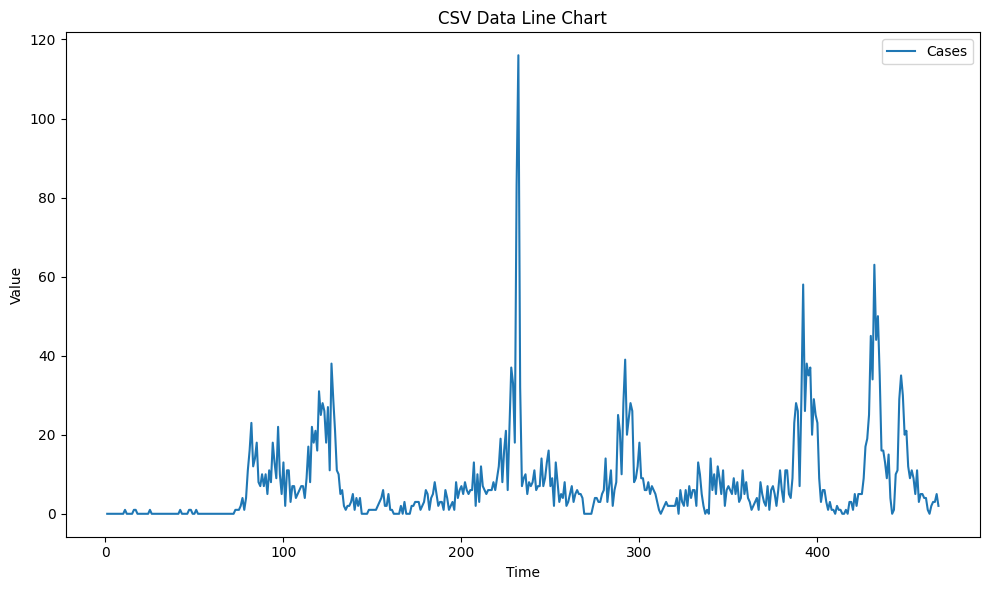

In [10]:
# Replace with the path to your CSV file
iquitos_csv = 'iquitos/DataIquitos_full.csv'
time_column = 'Epidemic_Week'
value_columns = ['Cases']

# Plot all data
plot_csv_data(iquitos_csv, time_column, value_columns, start=None, end=None)

     Epidemic_Week  Cases
265            266      5
266            267      5
267            268      4
268            269      0
269            270      0
270            271      0
271            272      0
272            273      0
273            274      2
274            275      4
275            276      4
276            277      3
277            278      3
278            279      5
279            280      6
280            281     14
281            282      3
282            283      7
283            284     11
284            285      2
285            286      6
286            287      8
287            288     25
288            289     21
289            290     10
290            291     28
291            292     39
292            293     20
293            294     24
294            295     28
295            296     26
296            297      8
297            298      9
298            299     12
299            300     18
300            301      9
301            302      9
302         

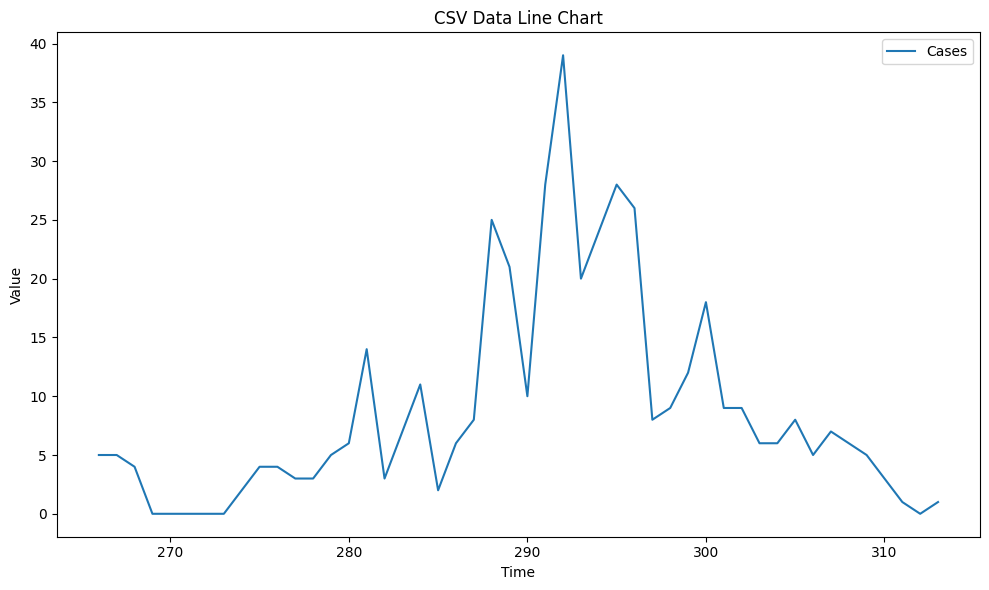

In [11]:
# Calibration (265-313)
plot_csv_data(iquitos_csv, time_column, value_columns, start=265, end=313)

In [12]:
import numpy as np

df = pd.read_csv(iquitos_csv)
df = df.iloc[265:313, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

265    1.791759
266    2.397895
267    2.708050
268    2.708050
269    2.708050
Name: CumulativeHumanInfected, dtype: float64
265     5.0
266    10.0
267    14.0
268    14.0
269    14.0
Name: CumulativeHumanInfected, dtype: float64
265      5
266     10
267     14
268     14
269     14
270     14
271     14
272     14
273     16
274     20
275     24
276     27
277     30
278     35
279     41
280     55
281     58
282     65
283     76
284     78
285     84
286     92
287    117
288    138
289    148
290    176
291    215
292    235
293    259
294    287
295    313
296    321
297    330
298    342
299    360
300    369
301    378
302    384
303    390
304    398
305    403
306    410
307    416
308    421
309    424
310    425
311    425
312    426
Name: CumulativeHumanInfected, dtype: int64


     Epidemic_Week  Cases
98              99      5
99             100     13
100            101      2
101            102     11
102            103     11
103            104      3
104            105      7
105            106      7
106            107      4
107            108      5
108            109      6
109            110      7
110            111      7
111            112      4
112            113      9
113            114     17
114            115      8
115            116     22
116            117     18
117            118     21
118            119     16
119            120     31
120            121     25
121            122     28
122            123     26
123            124     18
124            125     27
125            126     11
126            127     38
127            128     29
128            129     21
129            130     11
130            131     10
131            132      5
132            133      6
133            134      2
134            135      1
135         

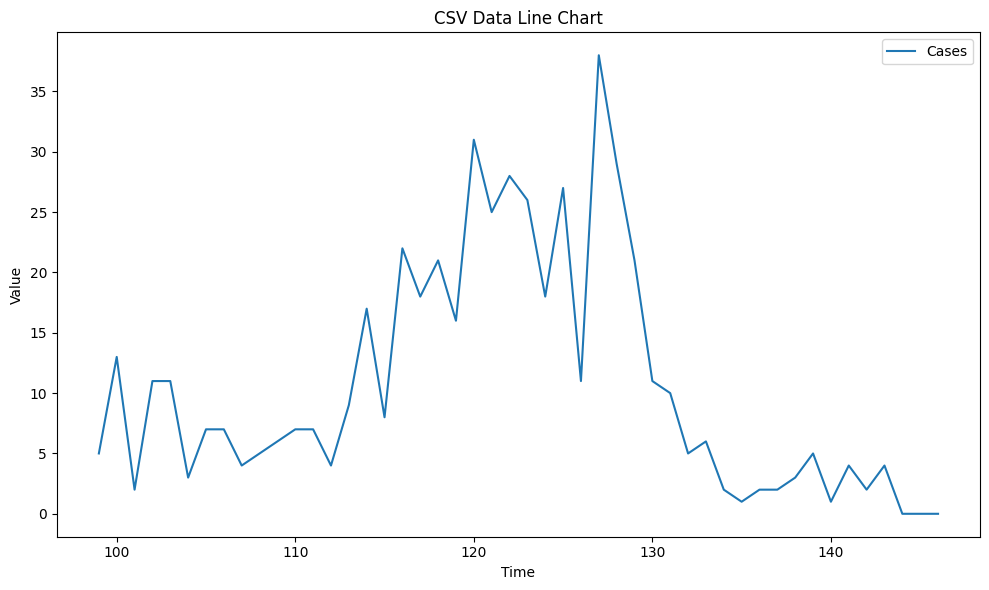

In [13]:
# Projection (99_160)
plot_csv_data(iquitos_csv, time_column, value_columns, start=98, end=146)

In [14]:
import numpy as np

df = pd.read_csv(iquitos_csv)
df = df.iloc[98:146, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

98     1.791759
99     2.944439
100    3.044522
101    3.465736
102    3.761200
Name: CumulativeHumanInfected, dtype: float64
98      5.0
99     18.0
100    20.0
101    31.0
102    42.0
Name: CumulativeHumanInfected, dtype: float64
98       5
99      18
100     20
101     31
102     42
103     45
104     52
105     59
106     63
107     68
108     74
109     81
110     88
111     92
112    101
113    118
114    126
115    148
116    166
117    187
118    203
119    234
120    259
121    287
122    313
123    331
124    358
125    369
126    407
127    436
128    457
129    468
130    478
131    483
132    489
133    491
134    492
135    494
136    496
137    499
138    504
139    505
140    509
141    511
142    515
143    515
144    515
145    515
Name: CumulativeHumanInfected, dtype: int64


In [21]:
import pandas as pd
import numpy as np

# Only use iquitos_origin to construct the output
iquitos_origin = pd.read_csv("iquitos/DataIquitos_full.csv")[98:146]

# Reset index for iquitos_origin
iquitos_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_iquitos = iquitos_origin[["Epidemic_Week", "Cases"]].copy()
data_iquitos["CumulativeHumanInfected"] = data_iquitos["Cases"].cumsum()
data_iquitos.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_iquitos = data_iquitos.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_iquitos[col] = np.nan

# Set "Date" as index
data_iquitos.set_index("Date", inplace=True)
data_iquitos.to_csv("iquitos/data_iquitos_proj.csv", index=True)

print(data_iquitos.shape)
data_iquitos.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
99,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# SanJuan dataset

In [ ]:
import pandas as pd
import numpy as np

# Only use sanjuan_origin to construct the output
sanjuan_origin = pd.read_csv("sanjuan/DataSanJuan_full.csv")[570:618]

# Reset index for sanjuan_origin
sanjuan_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_sanjuan = sanjuan_origin[["Epidemic_Week", "Cases"]].copy()
data_sanjuan["CumulativeHumanInfected"] = data_sanjuan["Cases"].cumsum()
data_sanjuan.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_sanjuan = data_sanjuan.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_sanjuan[col] = np.nan

# Set "Date" as index
data_sanjuan.set_index("Date", inplace=True)
data_sanjuan.to_csv("sanjuan/data_cali.csv", index=True)

print(data_sanjuan.shape)
data_sanjuan.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
571,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
572,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
573,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
574,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
575,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import h5py
import pandas as pd

# Read the CSV file
data_iquitos = pd.read_csv('sanjuan/data_cali.csv')
data_values = data_iquitos.iloc[:, 1:].values  # exclude the 'Date' column

# Reshape the data to (number of rows, 7, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(data_values.shape[0], data_values.shape[1], 1)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = 'sanjuan/data.h5'
with h5py.File(output_hdf5_path, 'w') as hdf:
    hdf.create_dataset('Dengue/true_counts', data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, 'r') as hdf:
    saved_shape = hdf['Dengue/true_counts'].shape
    print(f'Shape of true_counts from .h5 file {saved_shape}')

Shape of true_counts from .h5 file (48, 8, 1)


### Visualize the Dengue cases in Sanjuan

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_csv_data(csv_file, time_column, value_columns, start=None, end=None, title="CSV Data Line Chart", xlabel="Time", ylabel="Value"):
    # Load data from CSV using pandas
    df = pd.read_csv(csv_file)
    df = df.iloc[start:end, :] \
        if start is not None or end is not None else df
    print(df)
    
    plt.figure(figsize=(10, 6))
    for col in value_columns:
        plt.plot(df[time_column], df[col], label=col)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

     Epidemic_Week  Cases
0                1      4
1                2      5
2                3      4
3                4      3
4                5      6
..             ...    ...
983            984     24
984            985      9
985            986     21
986            987     10
987            988     15

[988 rows x 2 columns]


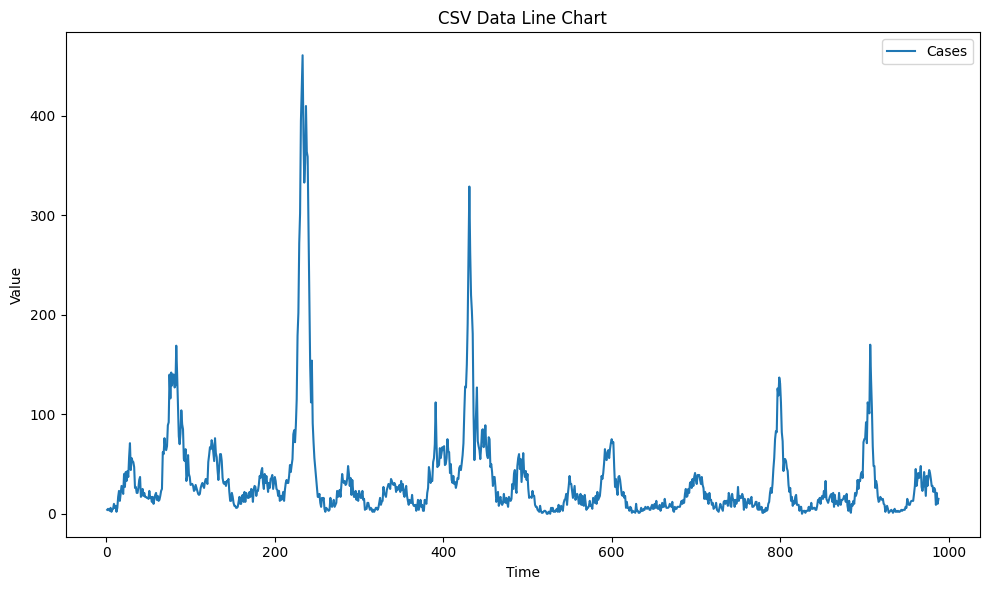

In [16]:
# Replace with the path to your CSV file
sanjuan_csv = 'sanjuan/DataSanJuan_full.csv'
time_column = 'Epidemic_Week'
value_columns = ['Cases']

# Plot raw data
plot_csv_data(sanjuan_csv, time_column, value_columns, start=None, end=None)

     Epidemic_Week  Cases
570            571      6
571            572      6
572            573      8
573            574     13
574            575      8
575            576      8
576            577      5
577            578     16
578            579     12
579            580     11
580            581     18
581            582     10
582            583     22
583            584     14
584            585     16
585            586     18
586            587     27
587            588     38
588            589     35
589            590     41
590            591     51
591            592     65
592            593     55
593            594     54
594            595     62
595            596     64
596            597     56
597            598     65
598            599     71
599            600     75
600            601     71
601            602     72
602            603     47
603            604     27
604            605     35
605            606     25
606            607     19
607         

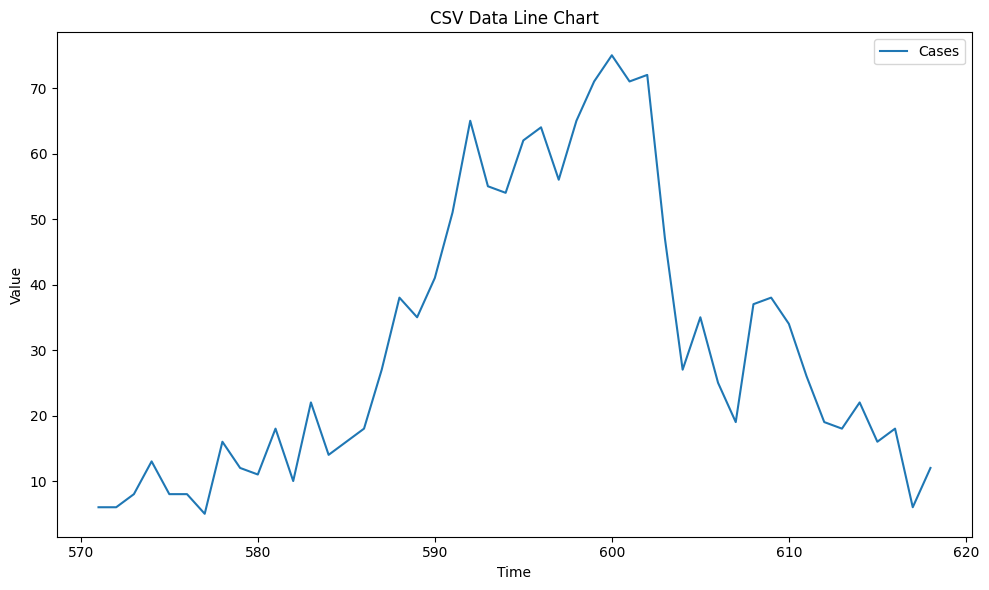

In [17]:
# Calibration (48 data points) (epidemic week: 570-618)
plot_csv_data(sanjuan_csv, time_column, value_columns, start=570, end=618)

In [20]:
import numpy as np

df = pd.read_csv(sanjuan_csv)
df = df.iloc[570:618, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

570    1.945910
571    2.564949
572    3.044522
573    3.526361
574    3.737670
Name: CumulativeHumanInfected, dtype: float64
570     6.0
571    12.0
572    20.0
573    33.0
574    41.0
Name: CumulativeHumanInfected, dtype: float64
570       6
571      12
572      20
573      33
574      41
575      49
576      54
577      70
578      82
579      93
580     111
581     121
582     143
583     157
584     173
585     191
586     218
587     256
588     291
589     332
590     383
591     448
592     503
593     557
594     619
595     683
596     739
597     804
598     875
599     950
600    1021
601    1093
602    1140
603    1167
604    1202
605    1227
606    1246
607    1283
608    1321
609    1355
610    1381
611    1400
612    1418
613    1440
614    1456
615    1474
616    1480
617    1492
Name: CumulativeHumanInfected, dtype: int64


     Epidemic_Week  Cases
467            468     17
468            469     10
469            470      9
470            471     11
471            472     20
472            473     13
473            474     11
474            475     16
475            476     11
476            477      7
477            478     17
478            479     14
479            480     13
480            481     15
481            482     30
482            483     25
483            484     40
484            485     44
485            486     25
486            487     21
487            488     48
488            489     56
489            490     60
490            491     45
491            492     55
492            493     32
493            494     46
494            495     61
495            496     42
496            497     37
497            498     43
498            499     34
499            500     40
500            501     25
501            502     16
502            503     17
503            504     17
504         

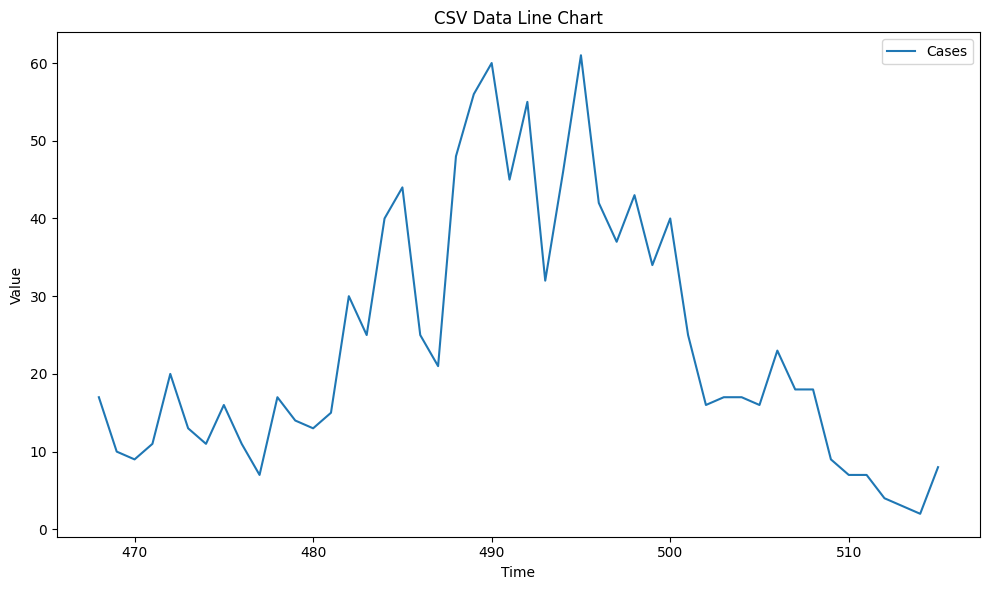

In [21]:
# Projection (48 data points)
plot_csv_data(sanjuan_csv, time_column, value_columns, start=467, end=515)

In [18]:
import numpy as np

df = pd.read_csv(sanjuan_csv)
df = df.iloc[467:515, :]
df["CumulativeHumanInfected"] = df["Cases"].cumsum()

print(np.log1p(df["CumulativeHumanInfected"]).head())
print(np.expm1(np.log1p(df["CumulativeHumanInfected"])).head())
print(df["CumulativeHumanInfected"])

467    2.890372
468    3.332205
469    3.610918
470    3.871201
471    4.219508
Name: CumulativeHumanInfected, dtype: float64
467    17.0
468    27.0
469    36.0
470    47.0
471    67.0
Name: CumulativeHumanInfected, dtype: float64
467      17
468      27
469      36
470      47
471      67
472      80
473      91
474     107
475     118
476     125
477     142
478     156
479     169
480     184
481     214
482     239
483     279
484     323
485     348
486     369
487     417
488     473
489     533
490     578
491     633
492     665
493     711
494     772
495     814
496     851
497     894
498     928
499     968
500     993
501    1009
502    1026
503    1043
504    1059
505    1082
506    1100
507    1118
508    1127
509    1134
510    1141
511    1145
512    1148
513    1150
514    1158
Name: CumulativeHumanInfected, dtype: int64


In [22]:
import pandas as pd
import numpy as np

# Only use sanjuan_origin to construct the output
sanjuan_origin = pd.read_csv("sanjuan/DataSanJuan_full.csv")[467:515]

# Reset index for sanjuan_origin
sanjuan_origin.reset_index(drop=True, inplace=True)

# Keep only the columns of interest, e.g., "Epidemic_Week" and "Cases"
data_sanjuan = sanjuan_origin[["Epidemic_Week", "Cases"]].copy()
data_sanjuan["CumulativeHumanInfected"] = data_sanjuan["Cases"].cumsum()
data_sanjuan.rename(columns={"Epidemic_Week": "Date"}, inplace=True)
data_sanjuan = data_sanjuan.drop(columns=["Cases"])

# Add columns for other compartments and fill with NaN
compartments = [
    "HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
    "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"
]
for col in compartments:
    data_sanjuan[col] = np.nan

# Set "Date" as index
data_sanjuan.set_index("Date", inplace=True)
data_sanjuan.to_csv("sanjuan/data_sanjuan_proj.csv", index=True)

print(data_sanjuan.shape)
data_sanjuan.head()

(48, 8)


,CumulativeHumanInfected,HumanInfected,MosquitoExposed,HumanRecovered,HumanSusceptible,HumanExposed,MosquitoSusceptible,MosquitoInfected
Date,,,,,,,,
468,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
469,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
470,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
472,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Vietnam dataset

In [4]:
import h5py
import numpy as np
import pandas as pd

# Read the CSV file
data_vietnam = pd.read_csv('vietnam/vietnam_data_1.csv')
columns = ["HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
           "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"]
for col in columns:
    data_vietnam[col] = np.nan
data_values = data_vietnam.values  # select the relevant columns

# Reshape the data to (num_rows, num_compartments, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(data_values.shape[0], data_values.shape[1], 1)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = 'vietnam/data.h5'
with h5py.File(output_hdf5_path, 'w') as hdf:
    hdf.create_dataset('Dengue/true_counts', data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, 'r') as hdf:
    saved_shape = hdf['Dengue/true_counts'].shape
    print(f'Shape of true_counts from .h5 file {saved_shape}')

Shape of true_counts from .h5 file (48, 8, 1)


# Philippines dataset

In [6]:
import h5py
import numpy as np
import pandas as pd

# Read the CSV file
data_philippines = pd.read_csv('philippines/philippines_data_1.csv')
columns = ["HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
           "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"]
for col in columns:
    data_philippines[col] = np.nan
data_values = data_philippines.values  # select the relevant columns

# Reshape the data to (num_rows, num_compartments, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(data_values.shape[0], data_values.shape[1], 1)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = 'philippines/data.h5'
with h5py.File(output_hdf5_path, 'w') as hdf:
    hdf.create_dataset('Dengue/true_counts', data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, 'r') as hdf:
    saved_shape = hdf['Dengue/true_counts'].shape
    print(f'Shape of true_counts from .h5 file {saved_shape}')

Shape of true_counts from .h5 file (48, 8, 1)


# Cambodia dataset

In [2]:
import h5py
import numpy as np
import pandas as pd

# Read the CSV file
data_cambodia = pd.read_csv('cambodia/cambodia_data_2.csv')
columns = ["HumanInfected", "MosquitoExposed", "HumanRecovered", "HumanSusceptible",
           "HumanExposed", "MosquitoSusceptible", "MosquitoInfected"]
for col in columns:
    data_cambodia[col] = np.nan
data_values = data_cambodia.values  # select the relevant columns

# Reshape the data to (num_rows, num_compartments, 1) to match the available columns in CSV
reshaped_data_values = data_values.reshape(data_values.shape[0], data_values.shape[1], 1)

# Save the reshaped data into a new HDF5 file
output_hdf5_path = 'cambodia/data.h5'
with h5py.File(output_hdf5_path, 'w') as hdf:
    hdf.create_dataset('Dengue/true_counts', data=reshaped_data_values)

# Confirm the saved file structure
with h5py.File(output_hdf5_path, 'r') as hdf:
    saved_shape = hdf['Dengue/true_counts'].shape
    print(f'Shape of true_counts from .h5 file {saved_shape}')

Shape of true_counts from .h5 file (48, 8, 1)
